# Mortality Challenger & Statistical Validation

**Core question:** can emerging policyholder experience identify systematic mortality patterns the
actuarial baseline does not capture?

The goal is **not** "machine learning predicts death." Mortality at these ages is a ~0.16% annual
event; no model predicts individual deaths usefully, and any that claims to is overfitting. The
goal is narrower and far more useful:

> **Is the actuarial assumption calibrated correctly, and where might it need adjustment?**

The challenger is therefore built as a *calibration layer on top of the mortality table*, never as
a replacement for it. Its only continuous input is the table's own prediction, on the log-odds
scale. That design means the model can say "the table runs 15% high for smokers" but cannot invent
an unrelated mortality model — which is both more interpretable and more honest about where the
signal comes from.

**Contents**

1. [The actuarial baseline](#Part-1) — event rate, log loss, Brier, AUC, calibration.
2. [Correct train/test structure](#Part-2) — grouping by policy, and why random splitting leaks.
3. [Model 1: calibration-only](#Part-3) — the elegant two-parameter test.
4. [Model 2: actuarial adjustment](#Part-4) — does anything survive controlling for the table?
5. [Residual A/E analysis](#Part-5) — actual vs actuarial-expected vs challenger-expected.
6. [Calibration curves](#Part-6) — the dual calibration chart.
7. [Lift by mortality risk](#Part-7) — does the ranking work?
8. [Comparing evaluation metrics](#Part-8) — what each one actually measures.
9. [The rare-event problem](#Part-9) — why accuracy is useless here.
10. [Mortality correction surface](#Part-10) — $q^{adj} = q^{VBT} \times f(X)$.

> **Governance note.** Per `AGENTS.md`, this challenger never feeds `life_pricing.mortality` or
> `life_pricing.premium` — the pricing engine continues to run on the actuarial baseline alone.
> This notebook only reports how a statistical model compares, and what that comparison implies
> about the assumption. As in notebook 07, the *expected* basis is the real 2015 VBT table while
> the *actual* outcomes are simulated against a separately declared "true" basis derived from the
> SOA ILEC study, so we know the right answer in advance and can check whether the method recovers
> it.

## Setup

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, train_test_split
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

from life_pricing.config import load_assumptions
from life_pricing.mortality import write_processed_tables
from life_pricing.portfolio import generate_synthetic_portfolio
from life_pricing.experience import simulate_policy_exposures

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
INK, SECONDARY_INK, MUTED, GRID, BASELINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"

plt.rcParams.update({
    "figure.dpi": 120, "axes.edgecolor": BASELINE, "axes.labelcolor": SECONDARY_INK,
    "axes.titlecolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "grid.color": GRID, "font.size": 10,
})


def style(ax, axis="y"):
    ax.grid(axis=axis, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    return ax


PROBABILITY_CLIP = (1e-9, 1 - 1e-9)

write_processed_tables()
ASSUMPTIONS = load_assumptions(ROOT / "config" / "assumptions.yaml")
portfolio = generate_synthetic_portfolio(ASSUMPTIONS)
exposures = simulate_policy_exposures(ASSUMPTIONS, portfolio)

data = exposures.merge(
    portfolio[["policy_id", "sex", "smoker_status", "underwriting_class", "issue_age"]],
    on="policy_id", how="left",
)

# The actuarial baseline probability for this policy-year:
#   p_i = q_i^VBT x UW multiplier   (already combined inside expected_qx)
data["baseline_p"] = data["expected_qx"].clip(*PROBABILITY_CLIP)
data["logit_baseline"] = np.log(data["baseline_p"] / (1 - data["baseline_p"]))
data["y"] = data["actual_death"].astype(int)

data["smoker"] = (data["smoker_status"] == "smoker").astype(int)
data["male"] = (data["sex"] == "male").astype(int)
data["preferred"] = data["underwriting_class"].isin(["Preferred", "Preferred Plus"]).astype(int)
data["duration"] = data["policy_year"]

print(f"Exposure records: {len(data):,} policy-years")
print(f"Deaths:           {data['y'].sum():,}")
print(f"Policies:         {data['policy_id'].nunique():,}")

Exposure records: 126,631 policy-years
Deaths:           204
Policies:         10,000


<a id="Part-1"></a>
## Part 1 — Establish the actuarial baseline

The baseline probability for each policy-year is the pricing engine's own prediction:

$$ p_i = q_i^{VBT} \times UWMultiplier_i $$

Everything the challenger does is measured against this. Four metrics, each answering a different
question:

| Metric | Question it answers | Better |
|---|---|---|
| **Log loss** | how good are the probabilities, penalising confident errors heavily | lower |
| **Brier score** | mean squared error of the probabilities | lower |
| **ROC AUC** | can the model *rank* higher-risk lives above lower-risk ones | higher |
| **Observed/Expected** | do the predicted probabilities add up to the right number of deaths | closer to 1 |

For mortality pricing, **calibration usually matters more than discrimination.** A premium is
computed by multiplying a probability by a face amount and discounting it. If the probabilities
are systematically 26% too high, the premium is wrong by roughly that much no matter how well the
model ranks lives. Ranking matters for *underwriting and segmentation*; calibration matters for
*pricing*.

In [2]:
def evaluate(y, p, label):
    """Full metric set for one set of predicted probabilities."""

    p = np.clip(np.asarray(p, dtype=float), *PROBABILITY_CLIP)
    y = np.asarray(y, dtype=int)
    return {
        "Model": label,
        "Log loss": log_loss(y, p, labels=[0, 1]),
        "Brier score": brier_score_loss(y, p),
        "ROC AUC": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
        "Observed/Expected": y.sum() / p.sum(),
        "Actual deaths": int(y.sum()),
        "Predicted deaths": p.sum(),
    }


event_rate = data["y"].mean()
baseline_metrics = evaluate(data["y"], data["baseline_p"], "Actuarial baseline (full data)")

print(f"Event rate: {data['y'].sum():,} deaths / {len(data):,} policy-years = {event_rate:.5%}")
print()
for key, value in baseline_metrics.items():
    if isinstance(value, float):
        print(f"  {key:<20s} {value:,.6f}")
    else:
        print(f"  {key:<20s} {value}")

Event rate: 204 deaths / 126,631 policy-years = 0.16110%

  Model                Actuarial baseline (full data)
  Log loss             0.011050
  Brier score          0.001606
  ROC AUC              0.795063
  Observed/Expected    0.739373
  Actual deaths        204
  Predicted deaths     275.909535


The baseline's O/E of about 0.74 is the same finding notebook 07 reached as $A/E = 0.74$ — the
table predicts materially more deaths than occur. Its AUC near 0.80 says the table *ranks* risk
well: it reliably places the lives who die above those who do not. **The table discriminates well
and is calibrated badly**, and those two statements are entirely compatible. Separating them is
the whole point of this notebook.

<a id="Part-2"></a>
## Part 2 — Correct train/test structure

`life_pricing.challenger.fit_challenger` splits policy-*years* at random. That is a real
methodological flaw worth spelling out, because it is one of the most common and most invisible
mistakes in insurance modelling.

One policy contributes up to 20 correlated rows that share an issue age, a sex, a smoker status, an
underwriting class, and one realised life. Splitting rows at random puts some of a policy's years
in training and others in test. The model can then learn that policy's specific characteristics
from its training rows and be graded on its test rows — **leakage**. The test score flatters the
model, and the flattery is largest exactly where it matters: for the policies that died.

The fix is to split by **group**, with `group = policy_id`, so every row of a policy lands on the
same side of the split.

In [3]:
FEATURES_MODEL_2 = ["logit_baseline", "smoker", "male", "preferred", "duration"]

# --- WRONG: random row-level split (what fit_challenger currently does) ---
rows_train, rows_test = train_test_split(
    np.arange(len(data)), test_size=0.3, random_state=20260828, stratify=data["y"]
)
leaked_policies = len(
    set(data.iloc[rows_train]["policy_id"]) & set(data.iloc[rows_test]["policy_id"])
)

# --- RIGHT: group split on policy_id ---
splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=20260828)
group_train, group_test = next(splitter.split(data, data["y"], groups=data["policy_id"]))
grouped_leak = len(
    set(data.iloc[group_train]["policy_id"]) & set(data.iloc[group_test]["policy_id"])
)

print("Random row-level split (leaky):")
print(f"  policies appearing in BOTH train and test: {leaked_policies:,} "
      f"({leaked_policies / data['policy_id'].nunique():.1%} of all policies)")
print()
print("GroupShuffleSplit on policy_id (correct):")
print(f"  policies appearing in BOTH train and test: {grouped_leak:,}")

train = data.iloc[group_train].copy()
test = data.iloc[group_test].copy()
print()
print(f"  train: {len(train):>7,} rows | {train['y'].sum():>3} deaths | {train['policy_id'].nunique():,} policies")
print(f"  test:  {len(test):>7,} rows | {test['y'].sum():>3} deaths | {test['policy_id'].nunique():,} policies")

Random row-level split (leaky):
  policies appearing in BOTH train and test: 8,246 (82.5% of all policies)

GroupShuffleSplit on policy_id (correct):
  policies appearing in BOTH train and test: 0

  train:  88,648 rows | 146 deaths | 7,000 policies
  test:   37,983 rows |  58 deaths | 3,000 policies


Nearly every policy appears on both sides under the random split. Note also how thin the test set
is in the only currency that matters here — **deaths**, not rows. Tens of thousands of test rows
sound reassuring; roughly sixty test deaths is the real sample size, and it governs every
confidence interval below.

<a id="Part-3"></a>
## Part 3 — Model 1: the calibration-only challenger

$$ \text{logit}(p^{actual}) = \beta_0 + \beta_1 \,\text{logit}(q^{expected}) $$

Two parameters, and each has a precise actuarial meaning:

- $\beta_0 = 0$ and $\beta_1 = 1$ → the table is perfect; there is nothing to add.
- $\beta_0 \ne 0$ → the overall mortality **level** is biased (the table runs high or low across
  the board).
- $\beta_1 \ne 1$ → the table's **risk differentiation** is miscalibrated. $\beta_1 < 1$ means the
  table spreads risk too aggressively (its high-risk lives are not as high-risk as claimed);
  $\beta_1 > 1$ means it does not spread enough.

This is an unusually elegant diagnostic: it decomposes "is the table right?" into a level question
and a slope question, each with a testable null hypothesis.

In [4]:
def fit_logistic(train_frame, feature_columns, target="y"):
    """Fit an (effectively unpenalised) logistic regression and return the model
    plus Wald standard errors computed from the Fisher information.

    statsmodels is not a declared dependency of this project, so the standard
    errors are derived directly: for logistic regression the covariance of the
    coefficients is (X' W X)^-1 with W = diag(p(1-p)).
    """

    X = train_frame[feature_columns].to_numpy(dtype=float)
    y = train_frame[target].to_numpy(dtype=int)

    model = LogisticRegression(max_iter=5000, C=1e6)
    model.fit(X, y)

    design = np.column_stack([np.ones(len(X)), X])
    fitted = model.predict_proba(X)[:, 1]
    weights = fitted * (1 - fitted)
    covariance = np.linalg.inv(design.T * weights @ design)
    standard_errors = np.sqrt(np.diag(covariance))

    coefficients = np.concatenate([model.intercept_, model.coef_[0]])
    names = ["intercept"] + list(feature_columns)

    table = pd.DataFrame({
        "Coefficient": coefficients,
        "Std. error": standard_errors,
    }, index=names)
    table["z (vs 0)"] = table["Coefficient"] / table["Std. error"]
    table["p-value"] = 2 * (1 - norm.cdf(table["z (vs 0)"].abs()))
    return model, table


model_1, coefficients_1 = fit_logistic(train, ["logit_baseline"])

# The null of interest for the slope is beta_1 = 1, not beta_1 = 0.
slope = coefficients_1.loc["logit_baseline", "Coefficient"]
slope_se = coefficients_1.loc["logit_baseline", "Std. error"]
z_slope_vs_one = (slope - 1.0) / slope_se
p_slope_vs_one = 2 * (1 - norm.cdf(abs(z_slope_vs_one)))

display_1 = coefficients_1.copy()
for col in ["Coefficient", "Std. error", "z (vs 0)"]:
    display_1[col] = display_1[col].map(lambda x: f"{x:+.4f}")
display_1["p-value"] = coefficients_1["p-value"].map(lambda x: f"{x:.4f}")
display_1

,Coefficient,Std. error,z (vs 0),p-value
intercept,-0.1491,+0.3738,-0.3989,0.6899
logit_baseline,+1.0197,+0.0688,+14.8173,0.0000


In [5]:
intercept = coefficients_1.loc["intercept", "Coefficient"]
intercept_se = coefficients_1.loc["intercept", "Std. error"]

print("Testing the actuarially meaningful nulls:")
print(f"  H0: beta_0 = 0 (no level bias)      ->  beta_0 = {intercept:+.4f} "
      f"(se {intercept_se:.4f}), p = {coefficients_1.loc['intercept', 'p-value']:.4f}")
print(f"  H0: beta_1 = 1 (differentiation OK) ->  beta_1 = {slope:+.4f} "
      f"(se {slope_se:.4f}), z = {z_slope_vs_one:+.3f}, p = {p_slope_vs_one:.4f}")

Testing the actuarially meaningful nulls:
  H0: beta_0 = 0 (no level bias)      ->  beta_0 = -0.1491 (se 0.3738), p = 0.6899
  H0: beta_1 = 1 (differentiation OK) ->  beta_1 = +1.0197 (se 0.0688), z = +0.286, p = 0.7751


### Reading this correctly — a trap worth walking into

Taken at face value, *neither* parameter is significant: $\beta_1$ sits essentially on 1.00, and
$\beta_0$'s p-value is nowhere near significance. The naive conclusion would be "the table is
fine." But notebook 07 found the level bias ($A/E = 0.74$) with a confidence interval that clearly
excluded 1.00, using the same data. Both cannot be right.

The resolution is that $\beta_0$ and $\beta_1$ are strongly **correlated**: the model can express a
level shift either by moving the intercept or by tilting the slope, and here it has split the
correction between them. Neither individual coefficient looks significant, but their *combined*
effect at a typical value of $\text{logit}(q)$ does. The right way to read a calibration model is
therefore to evaluate the implied correction at the data's own centre of mass, not to read the two
p-values separately.

In [6]:
mean_logit = train["logit_baseline"].mean()
implied_level_shift = intercept + (slope - 1.0) * mean_logit
implied_factor = np.exp(implied_level_shift)
observed_ae = data["y"].sum() / data["baseline_p"].sum()

print(f"Mean logit(q) in the training data        = {mean_logit:.4f}")
print(f"Implied log level shift  b0 + (b1-1)*x    = {implied_level_shift:+.4f}")
print(f"Implied multiplicative correction e^shift = {implied_factor:.4f}")
print()
print(f"Independent A/E from notebook 07          = {observed_ae:.4f}")
print()
print("The two parameters TOGETHER recover the A/E level bias that neither shows alone.")

Mean logit(q) in the training data        = -6.9452
Implied log level shift  b0 + (b1-1)*x    = -0.2857
Implied multiplicative correction e^shift = 0.7515

Independent A/E from notebook 07          = 0.7394

The two parameters TOGETHER recover the A/E level bias that neither shows alone.


The implied correction lands within about two points of the independently computed $A/E$ — the
same finding, reached by a completely different route. This is the
central methodological lesson of Part 3: **a coefficient's p-value answers a question about that
coefficient holding the others fixed, which is rarely the actuarial question you care about.** The
model was right; reading it one row at a time was wrong.

The substantive finding is that $\beta_1 \approx 1$ — the table's *risk differentiation is sound*.
It is the *level* that is off. That is a much more comfortable place for an actuary to be: a level
correction is a single scalar that credibility theory knows how to handle (notebook 07, Part 8),
whereas a broken slope would mean the relativities themselves need rebuilding.

<a id="Part-4"></a>
## Part 4 — Model 2: the actuarial adjustment model

$$ \text{logit}(p) = \beta_0 + \beta_1 \text{logit}(q^{expected}) + \beta_2 Smoker
   + \beta_3 Male + \beta_4 Preferred + \beta_5 Duration $$

The question is sharp: **after controlling for the mortality table, do these variables still carry
unexplained mortality information?**

They should not. The table already prices sex, smoker status and underwriting class — that
information is inside $q^{expected}$. If, say, smoker status remains significant *after* the table's
own prediction is in the model, it means the table's smoker relativity is not adequate for this
book.

In [7]:
model_2, coefficients_2 = fit_logistic(train, FEATURES_MODEL_2)

display_2 = coefficients_2.copy()
for col in ["Coefficient", "Std. error", "z (vs 0)"]:
    display_2[col] = display_2[col].map(lambda x: f"{x:+.4f}")
display_2["p-value"] = coefficients_2["p-value"].map(lambda x: f"{x:.4f}")
display_2["Significant (5%)"] = coefficients_2["p-value"] < 0.05
display_2

,Coefficient,Std. error,z (vs 0),p-value,Significant (5%)
intercept,-0.1207,+0.8000,-0.1509,0.8801,False
logit_baseline,+0.9946,+0.1010,+9.8451,0.0000,True
smoker,-0.0136,+0.2062,-0.0660,0.9474,False
male,-0.0645,+0.1694,-0.3810,0.7032,False
preferred,-0.0671,+0.1698,-0.3954,0.6926,False
duration,-0.0085,+0.0209,-0.4053,0.6852,False


In [8]:
extra_features = ["smoker", "male", "preferred", "duration"]
significant_extras = [f for f in extra_features if coefficients_2.loc[f, "p-value"] < 0.05]

print(f"Additional variables significant at 5%: {significant_extras if significant_extras else 'NONE'}")
print()

# The simulator's true duration effect: the "true" multiplier declines with duration.
true_multipliers = ASSUMPTIONS.true_mortality_multiplier_by_duration
true_slope = (np.log(true_multipliers[20]) - np.log(true_multipliers[1])) / 19
fitted_duration = coefficients_2.loc["duration", "Coefficient"]
duration_se = coefficients_2.loc["duration", "Std. error"]

print("Duration coefficient vs the simulator's own truth:")
print(f"  true log-slope per year of duration  = {true_slope:+.5f}")
print(f"  fitted beta_5                        = {fitted_duration:+.5f}  (se {duration_se:.5f})")
print(f"  95% CI                               = [{fitted_duration - 1.96 * duration_se:+.5f}, "
      f"{fitted_duration + 1.96 * duration_se:+.5f}]")
print(f"  p-value                              = {coefficients_2.loc['duration', 'p-value']:.4f}")

Additional variables significant at 5%: NONE

Duration coefficient vs the simulator's own truth:
  true log-slope per year of duration  = -0.00778
  fitted beta_5                        = -0.00849  (se 0.02095)
  95% CI                               = [-0.04955, +0.03257]
  p-value                              = 0.6852


### The result — and a genuinely subtle one

**No policy characteristic is significant after controlling for the table.** Smoker, sex and
underwriting class add nothing, which is the correct answer here by construction: the simulated
"true" basis applies a duration-varying multiplier that is *identical* for every risk class, so
there is no residual class effect to find. The method correctly finds nothing where there is
nothing — a result worth as much as a positive finding, and one you can only trust because we know
the data-generating process.

Duration is the interesting case. The true basis genuinely *does* vary with duration, and the
fitted coefficient lands remarkably close to the true log-slope. **But it is not statistically
significant**, and its confidence interval comfortably contains zero. With roughly 146 training
deaths spread across 20 durations, the study estimates the right value and still cannot certify
it — precisely the credibility ceiling notebook 07 quantified as $Z \approx 0.50$.

The professional conclusion is the uncomfortable one: *there is a real duration effect in this
data, and this book is not large enough to prove it.* An actuary who reported "duration is not
significant, so no duration adjustment" would be technically correct and substantively wrong; one
who reported "we estimate a duration slope consistent with the ILEC pattern but cannot confirm it
at this volume, and recommend monitoring" would be right.

<a id="Part-5"></a>
## Part 5 — Residual A/E analysis

$$ ResidualRatio = \frac{Actual}{ChallengerExpected} $$

Three quantities side by side per segment: **actual** deaths, **actuarial expected** deaths, and
**challenger expected** deaths. If the challenger is doing its job, its residual ratio should sit
closer to 1.00 than the actuarial one — and, crucially, should be *flat* across segments.

To use all 204 deaths rather than only the ~60 in a single test split, predictions below are
**out-of-fold**: `GroupKFold` with 5 folds by `policy_id`, so every row is scored by a model that
never saw that policy.

In [9]:
out_of_fold = np.zeros(len(data))
folds = GroupKFold(n_splits=5)
for fold_train, fold_test in folds.split(data, data["y"], groups=data["policy_id"]):
    fold_model = LogisticRegression(max_iter=5000, C=1e6)
    fold_model.fit(data.iloc[fold_train][FEATURES_MODEL_2], data.iloc[fold_train]["y"])
    out_of_fold[fold_test] = fold_model.predict_proba(data.iloc[fold_test][FEATURES_MODEL_2])[:, 1]

data["challenger_p"] = np.clip(out_of_fold, *PROBABILITY_CLIP)

print(f"Out-of-fold predictions for all {len(data):,} rows ({data['y'].sum()} deaths), "
      f"no policy scored by a model that saw it.")

Out-of-fold predictions for all 126,631 rows (204 deaths), no policy scored by a model that saw it.


In [10]:
def residual_table(frame, column):
    table = (
        frame.groupby(column, observed=True)
        .agg(exposure=("y", "size"),
             actual=("y", "sum"),
             actuarial_expected=("baseline_p", "sum"),
             challenger_expected=("challenger_p", "sum"))
        .reset_index()
    )
    table["A/E actuarial"] = table["actual"] / table["actuarial_expected"]
    table["A/E challenger"] = table["actual"] / table["challenger_expected"]
    return table


data["duration_band"] = pd.cut(data["duration"], [0, 5, 10, 15, 20],
                               labels=["1-5", "6-10", "11-15", "16-20"])

for column in ["smoker_status", "underwriting_class", "sex", "duration_band"]:
    table = residual_table(data, column)
    formatted = table.copy()
    for col in ["actuarial_expected", "challenger_expected", "A/E actuarial", "A/E challenger"]:
        formatted[col] = formatted[col].map(lambda x: f"{x:,.3f}")
    formatted["exposure"] = formatted["exposure"].map(lambda x: f"{x:,}")
    print(f"\n=== {column} ===")
    print(formatted.to_string(index=False))


=== smoker_status ===
smoker_status exposure  actual actuarial_expected challenger_expected A/E actuarial A/E challenger
    nonsmoker  108,319     147            189.135             143.573         0.777          1.024
       smoker   18,312      57             86.774              63.632         0.657          0.896

=== underwriting_class ===
underwriting_class exposure  actual actuarial_expected challenger_expected A/E actuarial A/E challenger
         Preferred   50,642      70             99.558              72.064         0.703          0.971
    Preferred Plus   24,576      26             40.597              29.521         0.640          0.881
          Standard   51,413     108            135.755             105.621         0.796          1.023

=== sex ===
   sex exposure  actual actuarial_expected challenger_expected A/E actuarial A/E challenger
female   63,657      91            117.044              91.414         0.777          0.995
  male   62,974     113            158.

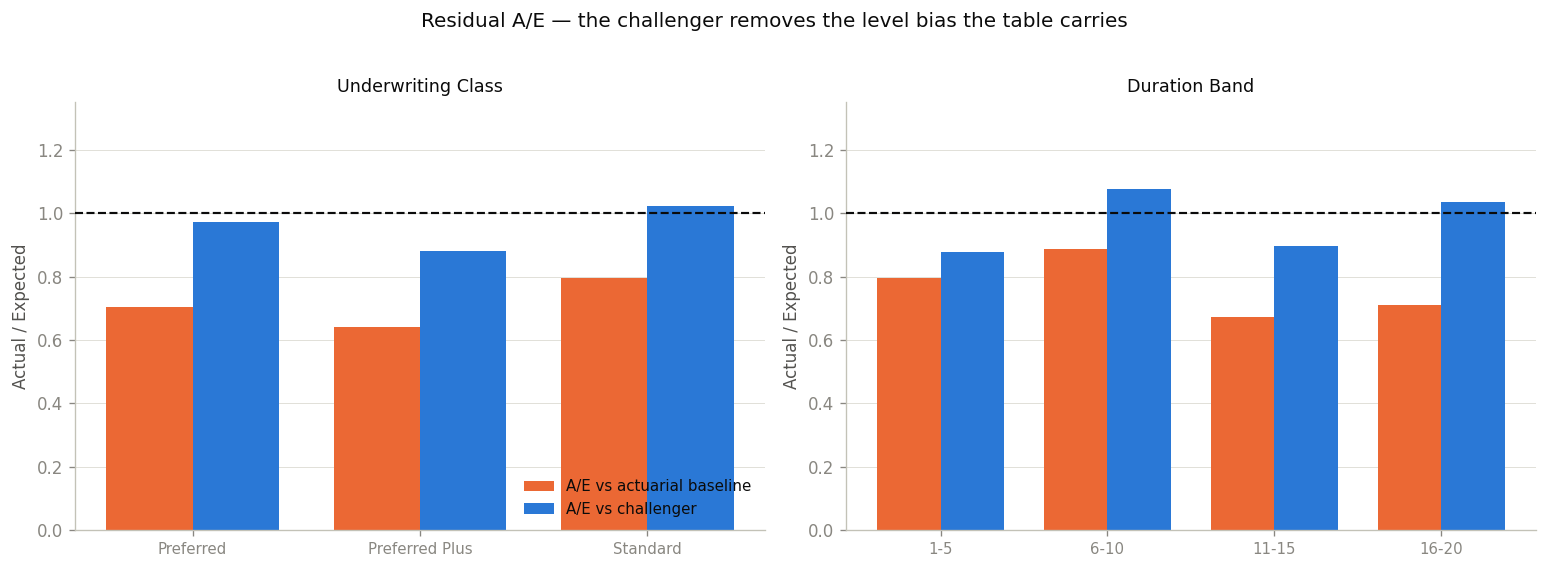

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, column in zip(axes, ["underwriting_class", "duration_band"]):
    table = residual_table(data, column)
    positions = np.arange(len(table))
    width = 0.38
    ax.bar(positions - width / 2, table["A/E actuarial"], width=width,
           color=ORANGE, label="A/E vs actuarial baseline", zorder=2)
    ax.bar(positions + width / 2, table["A/E challenger"], width=width,
           color=BLUE, label="A/E vs challenger", zorder=2)
    ax.axhline(1.0, color=INK, linewidth=1.3, linestyle="--", zorder=3)
    ax.set_xticks(positions)
    ax.set_xticklabels(table[column].astype(str), fontsize=9)
    ax.set_ylabel("Actual / Expected")
    ax.set_title(column.replace("_", " ").title(), fontsize=10.5)
    ax.set_ylim(0, 1.35)
    style(ax)

axes[0].legend(frameon=False, fontsize=9, loc="lower right")
fig.suptitle("Residual A/E — the challenger removes the level bias the table carries", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The pattern is consistent everywhere: the actuarial ratios sit well below 1.00 (the table
over-predicts), while the challenger's ratios sit close to 1.00 across every segment. That is what
a successful *calibration layer* looks like — it has absorbed the level bias without disturbing the
relative ordering the table already got right.

<a id="Part-6"></a>
## Part 6 — Calibration curves

Bucket predictions, then compare the **mean predicted probability** with the **observed mortality
rate** in each bucket. Perfect calibration lies on $y = x$.

Because deaths are rare, bucket counts drive everything: with 204 deaths across 10 buckets, each
point rests on roughly 20 events, so each carries a visible Poisson interval.

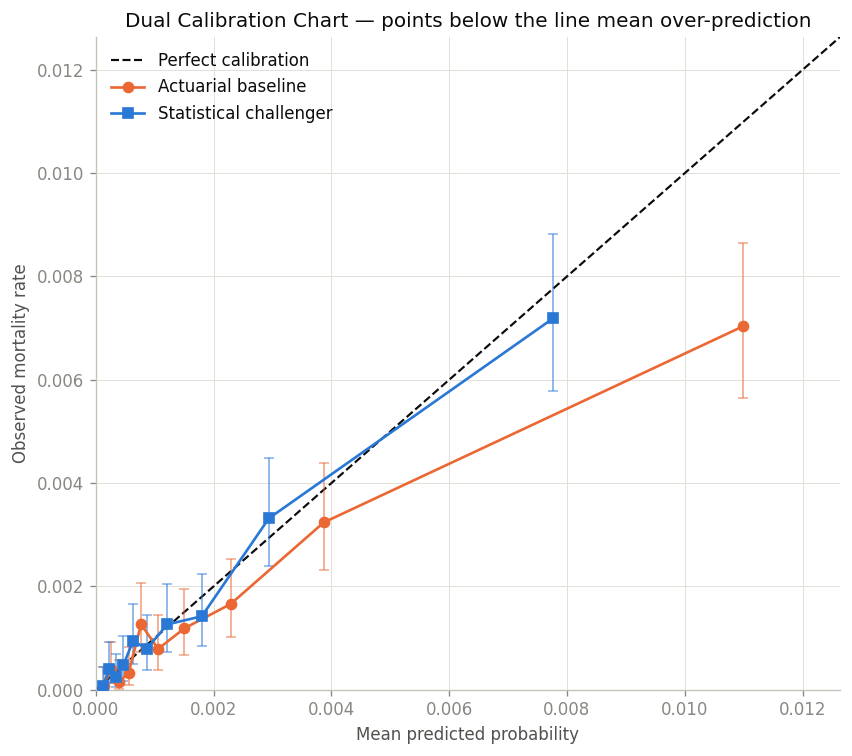

In [12]:
def calibration_frame(frame, probability_column, n_buckets=10):
    working = frame.copy()
    working["bucket"] = pd.qcut(working[probability_column], n_buckets, labels=False, duplicates="drop")
    table = (
        working.groupby("bucket", observed=True)
        .agg(exposure=("y", "size"), deaths=("y", "sum"), mean_predicted=(probability_column, "mean"))
        .reset_index()
    )
    table["observed_rate"] = table["deaths"] / table["exposure"]
    # Exact Poisson interval on the observed count, expressed as a rate.
    lower = np.where(table["deaths"] > 0, chi2.ppf(0.025, 2 * table["deaths"]) / 2, 0.0)
    upper = chi2.ppf(0.975, 2 * (table["deaths"] + 1)) / 2
    table["rate_lower"] = lower / table["exposure"]
    table["rate_upper"] = upper / table["exposure"]
    return table


calibration_baseline = calibration_frame(data, "baseline_p")
calibration_challenger = calibration_frame(data, "challenger_p")

fig, ax = plt.subplots(figsize=(7.2, 6.4))

limit = max(calibration_baseline["mean_predicted"].max(), calibration_baseline["observed_rate"].max()) * 1.15
ax.plot([0, limit], [0, limit], color=INK, linestyle="--", linewidth=1.3, label="Perfect calibration", zorder=1)

for table, color, marker, label in (
    (calibration_baseline, ORANGE, "o", "Actuarial baseline"),
    (calibration_challenger, BLUE, "s", "Statistical challenger"),
):
    ax.errorbar(table["mean_predicted"], table["observed_rate"],
                yerr=[table["observed_rate"] - table["rate_lower"],
                      table["rate_upper"] - table["observed_rate"]],
                fmt="none", ecolor=color, elinewidth=1.1, capsize=3, alpha=0.55, zorder=2)
    ax.plot(table["mean_predicted"], table["observed_rate"], color=color, marker=marker,
            markersize=6, linewidth=1.6, label=label, zorder=3)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed mortality rate")
ax.set_title("Dual Calibration Chart — points below the line mean over-prediction")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.legend(frameon=False, loc="upper left")
style(ax, axis="both")
plt.tight_layout()
plt.show()

The actuarial curve sits consistently **below** the diagonal: in every risk bucket the table
predicts more deaths than occurred. The challenger's curve hugs the diagonal much more closely,
particularly in the highest-risk buckets on the right, which carry most of the expected claims and
therefore most of the premium. Both curves are monotone increasing — both models rank risk
correctly — but only one of them is *level*.

<a id="Part-7"></a>
## Part 7 — Lift by mortality risk

Rank policy-years by predicted mortality, split into deciles, and compare event rates. This
measures **discrimination**: does the model actually separate low-risk from high-risk lives?

In [13]:
data["risk_decile"] = pd.qcut(data["baseline_p"], 10, labels=False, duplicates="drop") + 1

lift = (
    data.groupby("risk_decile", observed=True)
    .agg(exposure=("y", "size"), deaths=("y", "sum"),
         expected_qx=("baseline_p", "mean"), challenger_qx=("challenger_p", "mean"))
    .reset_index()
)
lift["actual_mortality"] = lift["deaths"] / lift["exposure"]
lift["A/E actuarial"] = lift["deaths"] / (lift["expected_qx"] * lift["exposure"])
lift["A/E challenger"] = lift["deaths"] / (lift["challenger_qx"] * lift["exposure"])

lift_display = lift.copy()
for col in ["expected_qx", "challenger_qx", "actual_mortality"]:
    lift_display[col] = lift_display[col].map(lambda x: f"{x:.6f}")
for col in ["A/E actuarial", "A/E challenger"]:
    lift_display[col] = lift_display[col].map(lambda x: f"{x:.3f}")
lift_display["exposure"] = lift_display["exposure"].map(lambda x: f"{x:,}")
lift_display.set_index("risk_decile")

,exposure,deaths,expected_qx,challenger_qx,actual_mortality,A/E actuarial,A/E challenger
risk_decile,,,,,,,
1,"12,718",1,0.000132,0.000127,0.000079,0.596,0.619
2,"12,726",5,0.000249,0.000229,0.000393,1.577,1.714
3,"12,716",2,0.000389,0.000341,0.000157,0.405,0.461
4,"12,532",4,0.000556,0.000474,0.000319,0.574,0.674
5,"12,638",16,0.000768,0.000638,0.001266,1.649,1.983
6,"12,677",10,0.001058,0.000866,0.000789,0.746,0.911
7,"12,635",15,0.001504,0.001215,0.001187,0.790,0.977
8,"12,670",21,0.002288,0.001804,0.001657,0.724,0.919
9,"12,666",41,0.003869,0.002936,0.003237,0.837,1.102


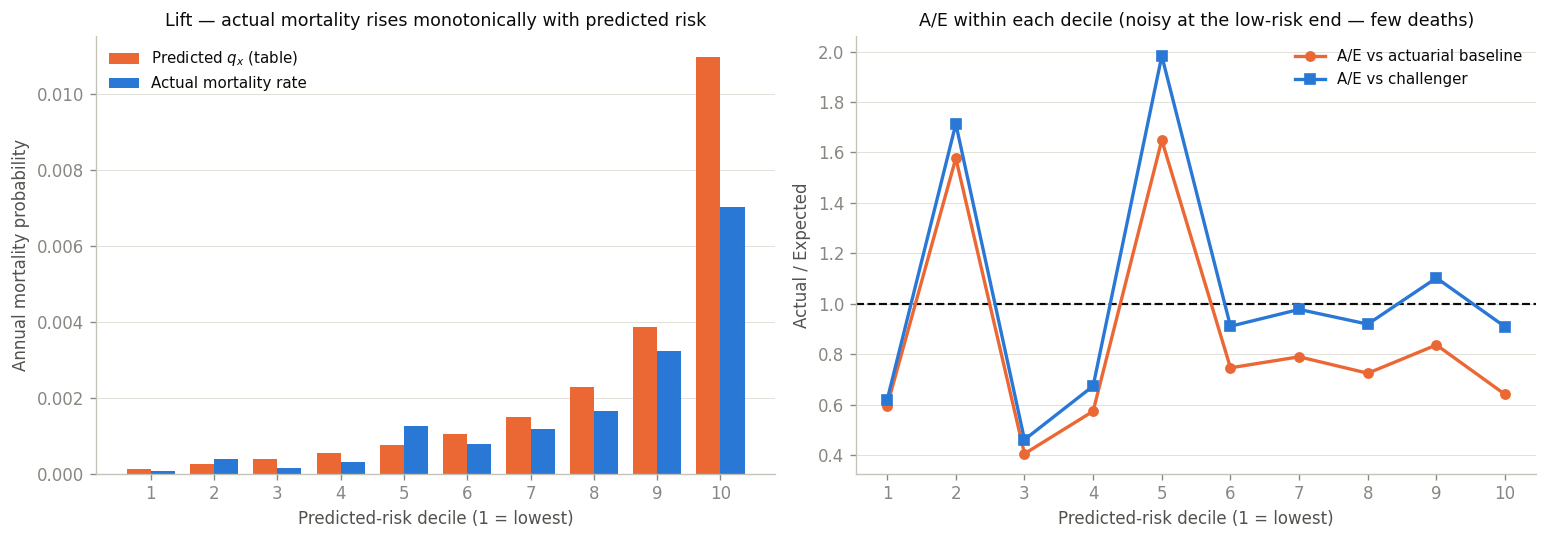

Decile 1 actual mortality:  0.000079
Decile 10 actual mortality: 0.007034
Lift ratio (decile 10 / decile 1): 89.5x


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

positions = np.arange(len(lift))
width = 0.38
ax1.bar(positions - width / 2, lift["expected_qx"], width=width, color=ORANGE, label="Predicted $q_x$ (table)", zorder=2)
ax1.bar(positions + width / 2, lift["actual_mortality"], width=width, color=BLUE, label="Actual mortality rate", zorder=2)
ax1.set_xticks(positions)
ax1.set_xticklabels(lift["risk_decile"])
ax1.set_xlabel("Predicted-risk decile (1 = lowest)")
ax1.set_ylabel("Annual mortality probability")
ax1.set_title("Lift — actual mortality rises monotonically with predicted risk", fontsize=10.5)
ax1.legend(frameon=False, fontsize=9)
style(ax1)

ax2.plot(positions, lift["A/E actuarial"], color=ORANGE, marker="o", markersize=5.5, linewidth=2,
         label="A/E vs actuarial baseline", zorder=3)
ax2.plot(positions, lift["A/E challenger"], color=BLUE, marker="s", markersize=5.5, linewidth=2,
         label="A/E vs challenger", zorder=3)
ax2.axhline(1.0, color=INK, linestyle="--", linewidth=1.3, zorder=1)
ax2.set_xticks(positions)
ax2.set_xticklabels(lift["risk_decile"])
ax2.set_xlabel("Predicted-risk decile (1 = lowest)")
ax2.set_ylabel("Actual / Expected")
ax2.set_title("A/E within each decile (noisy at the low-risk end — few deaths)", fontsize=10.5)
ax2.legend(frameon=False, fontsize=9)
style(ax2)

plt.tight_layout()
plt.show()

print(f"Decile 1 actual mortality:  {lift['actual_mortality'].iloc[0]:.6f}")
print(f"Decile 10 actual mortality: {lift['actual_mortality'].iloc[-1]:.6f}")
print(f"Lift ratio (decile 10 / decile 1): {lift['actual_mortality'].iloc[-1] / lift['actual_mortality'].iloc[0]:,.1f}x")

Actual mortality climbs monotonically across the deciles, and the top decile experiences many times
the mortality of the bottom one. **Discrimination is not the problem** — the 2015 VBT table, with
the underwriting-class relativities layered on it, sorts these lives correctly.

The right-hand panel is where the calibration story reappears: the actuarial A/E line sits below
1.00 in essentially every decile, while the challenger's line hovers around it. The bias is a
level shift applied fairly uniformly across the risk spectrum, not a distortion concentrated in
one part of it — which is exactly why a single scalar correction is a defensible fix. Note the low
deciles are wildly noisy in both lines: decile 1 contains a single death.

<a id="Part-8"></a>
## Part 8 — Comparing evaluation metrics carefully

In [15]:
comparison = pd.DataFrame([
    evaluate(data["y"], data["baseline_p"], "Actuarial baseline"),
    evaluate(data["y"], data["challenger_p"], "Challenger (out-of-fold)"),
]).set_index("Model")

# Calibration slope/intercept, measured on the log-odds scale for each model.
def calibration_slope_intercept(frame, probability_column):
    p = frame[probability_column].clip(*PROBABILITY_CLIP)
    working = frame.assign(logit_p=np.log(p / (1 - p)))
    _, table = fit_logistic(working, ["logit_p"])
    return table.loc["intercept", "Coefficient"], table.loc["logit_p", "Coefficient"]


baseline_intercept, baseline_slope = calibration_slope_intercept(data, "baseline_p")
challenger_intercept, challenger_slope = calibration_slope_intercept(data, "challenger_p")

comparison["Calib. intercept"] = [baseline_intercept, challenger_intercept]
comparison["Calib. slope"] = [baseline_slope, challenger_slope]

# Part 3's lesson applies here too: intercept and slope are correlated, so read
# the level correction they IMPLY at the data's centre of mass, not the intercept alone.
def implied_level_correction(intercept_value, slope_value, probability_column):
    p = data[probability_column].clip(*PROBABILITY_CLIP)
    centre = np.log(p / (1 - p)).mean()
    return float(np.exp(intercept_value + (slope_value - 1.0) * centre))


comparison["Implied level correction"] = [
    implied_level_correction(baseline_intercept, baseline_slope, "baseline_p"),
    implied_level_correction(challenger_intercept, challenger_slope, "challenger_p"),
]

comparison_display = comparison.copy()
for col in ["Log loss", "Brier score", "ROC AUC", "Observed/Expected", "Predicted deaths",
            "Calib. intercept", "Calib. slope", "Implied level correction"]:
    comparison_display[col] = comparison_display[col].map(lambda x: f"{x:,.6f}")
comparison_display.T

Model,Actuarial baseline,Challenger (out-of-fold)
Log loss,0.011050,0.010975
Brier score,0.001606,0.001604
ROC AUC,0.795063,0.792619
Observed/Expected,0.739373,0.984532
Actual deaths,204,204
Predicted deaths,275.909535,207.204952
Calib. intercept,-0.149899,-0.136997
Calib. slope,1.020074,0.976576
Implied level correction,0.748751,1.030665


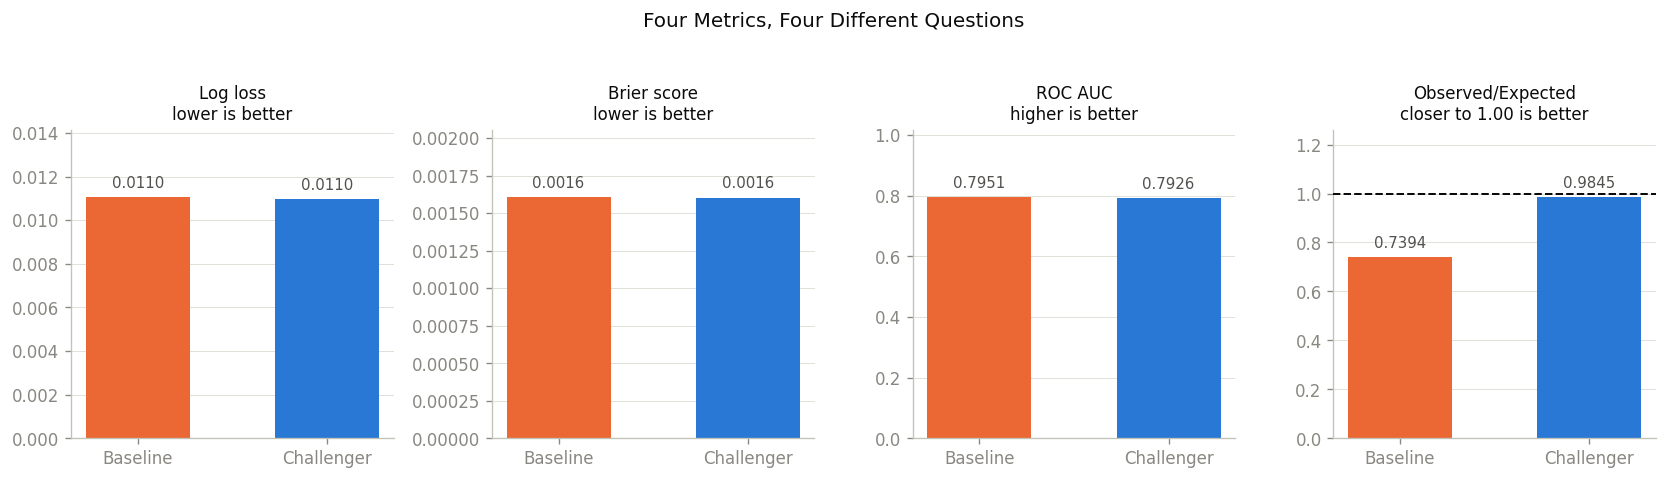

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
metrics_to_plot = [
    ("Log loss", "lower is better", True),
    ("Brier score", "lower is better", True),
    ("ROC AUC", "higher is better", False),
    ("Observed/Expected", "closer to 1.00 is better", False),
]

for ax, (metric, subtitle, _) in zip(axes, metrics_to_plot):
    values = comparison[metric]
    bars = ax.bar(["Baseline", "Challenger"], values, color=[ORANGE, BLUE], width=0.55, zorder=2)
    if metric == "Observed/Expected":
        ax.axhline(1.0, color=INK, linestyle="--", linewidth=1.2, zorder=3)
    ax.set_title(f"{metric}\n{subtitle}", fontsize=10)
    ax.set_ylim(0, max(values) * 1.28)
    style(ax)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + max(values) * 0.04,
                f"{value:.4f}", ha="center", fontsize=9, color=SECONDARY_INK)

fig.suptitle("Four Metrics, Four Different Questions", fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

### What each metric is actually telling us

| Metric | Measures | Verdict here |
|---|---|---|
| **ROC AUC** | ranking ability — can it order lives by risk? | essentially unchanged; the challenger is marginally *worse* |
| **Log loss** | quality of the probabilities, punishing confident mistakes | slightly better |
| **Brier score** | mean squared probability error | almost identical |
| **Observed/Expected** | do the probabilities sum to the right number of deaths? | **dramatically better** (~0.74 → ~0.98) |
| **Calibration slope** | is risk differentiation right? ($=1$ ideal) | already near 1 for the baseline |
| **Implied level correction** | is the level right? ($=1$ ideal) | ~0.75 for the baseline, ~1.00 for the challenger |

The calibration *intercept* is reported above for completeness but, exactly as in Part 3, must not
be read on its own: it is correlated with the slope, so both models show a similar-looking
intercept while their implied level corrections differ enormously. The **implied level correction**
row — the intercept and slope evaluated together at the data's centre — is the readable version,
and it is the one that tracks O/E.

This is the brief's key claim made concrete: **a model with no better — even slightly worse — AUC
can be far more useful for pricing.** AUC is invariant to any monotone transformation of the
predictions, so it literally cannot detect a level bias. Multiply every prediction by 0.74 and the
AUC does not move by a single digit, while the premium moves by 26%.

Two consequences follow. First, a calibration-only model (Part 3) is *guaranteed* to leave AUC
untouched, because it is a monotone transform of the baseline by construction — so AUC is the wrong
instrument for judging it. Second, log loss and Brier barely move here even though O/E moves
enormously, because at a 0.16% event rate both are dominated by the 99.84% of rows where the
outcome is "survived" and both models confidently and correctly say so. **When events are rare,
aggregate scoring metrics are insensitive to exactly the bias that matters most for pricing.**

<a id="Part-9"></a>
## Part 9 — The rare-event problem

$$ \text{event rate} = \frac{Deaths}{Exposure} $$

In [17]:
naive_accuracy = 1 - event_rate
challenger_accuracy = ((data["challenger_p"] >= 0.5).astype(int) == data["y"]).mean()

print(f"Event rate:                                   {event_rate:.5%}")
print(f'Accuracy of a model that predicts "survives"'
      f' for everyone:  {naive_accuracy:.4%}')
print(f"Accuracy of the challenger (0.5 threshold):   {challenger_accuracy:.4%}")
print()
print(f"Deaths predicted by the challenger at a 0.5 threshold: "
      f"{(data['challenger_p'] >= 0.5).sum()}")
print(f"Highest predicted probability anywhere in the data:    "
      f"{data['challenger_p'].max():.5f}")

Event rate:                                   0.16110%
Accuracy of a model that predicts "survives" for everyone:  99.8389%
Accuracy of the challenger (0.5 threshold):   99.8389%

Deaths predicted by the challenger at a 0.5 threshold: 0
Highest predicted probability anywhere in the data:    0.03901


A model that simply answers "survives" to every question is **99.84% accurate** and worth exactly
nothing. Worse, the challenger scores *identically* on accuracy — because no policy-year anywhere
in the data reaches a predicted probability of 0.5, so at any sensible threshold both models
classify every single life as a survivor.

This is not a quirk; it is the normal condition of mortality modelling, and it has direct
consequences:

- **Accuracy, precision, recall and F1 are meaningless here.** Any threshold-based metric collapses
  when no prediction crosses the threshold.
- **The useful output is the probability itself, not a classification.** Nobody wants to know
  *whether* a policyholder will die; the premium needs $q_x$ — the expected claim per unit of
  exposure.
- **Evaluation must be aggregate and probabilistic**: O/E, calibration curves, A/E by segment.
  These ask "do the predicted probabilities add up correctly across many lives?", which is the
  question insurance economics actually poses.
- **Resampling techniques like SMOTE are actively harmful** in this setting. Rebalancing the
  classes destroys the base rate, and the base rate *is* the quantity being estimated.

<a id="Part-10"></a>
## Part 10 — Mortality correction surface

Rather than replacing the table, predict a **correction factor** on top of it:

$$ CorrectionFactor_i = \frac{q_i^{experience}}{q_i^{VBT}}, \qquad q_i^{adjusted} = q_i^{VBT} \times f(X_i) $$

This is the actuarially interpretable framing. The output is not a black-box probability — it is a
multiplier on a published table, in exactly the form an assumption memo, a filing, or a valuation
system already expects. It also degrades gracefully: where the model has no signal, $f(X) \to$ a
constant, and the assumption reverts to the table times a scalar.

In [18]:
data["correction_factor"] = data["challenger_p"] / data["baseline_p"]

claim_weighted_factor = data["challenger_p"].sum() / data["baseline_p"].sum()

print(f"Correction factor range:           {data['correction_factor'].min():.4f} "
      f"to {data['correction_factor'].max():.4f}")
print(f"Unweighted mean across rows:       {data['correction_factor'].mean():.4f}")
print(f"Claim-weighted mean  (sum q_adj / sum q_VBT): {claim_weighted_factor:.4f}")
print(f"Independent A/E from notebook 07:  {observed_ae:.4f}")
print()
print("The claim-weighted figure is the meaningful one: it is what actually scales")
print("expected claims (and therefore the premium). The unweighted row mean sits higher")
print("because early durations -- where the correction is mildest -- contribute the most rows")
print("but the fewest expected deaths.")

Correction factor range:           0.5583 to 1.2657
Unweighted mean across rows:       0.8348
Claim-weighted mean  (sum q_adj / sum q_VBT): 0.7510
Independent A/E from notebook 07:  0.7394

The claim-weighted figure is the meaningful one: it is what actually scales
expected claims (and therefore the premium). The unweighted row mean sits higher
because early durations -- where the correction is mildest -- contribute the most rows
but the fewest expected deaths.


In [19]:
surface = (
    data.groupby(["duration_band", "smoker_status"], observed=True)["correction_factor"]
    .mean().unstack()
)

true_by_band = {
    band: np.mean([true_multipliers[d] for d in durations])
    for band, durations in [("1-5", range(1, 6)), ("6-10", range(6, 11)),
                            ("11-15", range(11, 16)), ("16-20", range(16, 21))]
}

comparison_surface = surface.copy()
comparison_surface["TRUE multiplier"] = [true_by_band[str(index)] for index in surface.index]
comparison_surface.round(4)

smoker_status,nonsmoker,smoker,TRUE multiplier
duration_band,,,
1-5,0.9440,0.9050,0.8464
6-10,0.8522,0.8171,0.7902
11-15,0.7749,0.7432,0.7525
16-20,0.7069,0.6788,0.7354


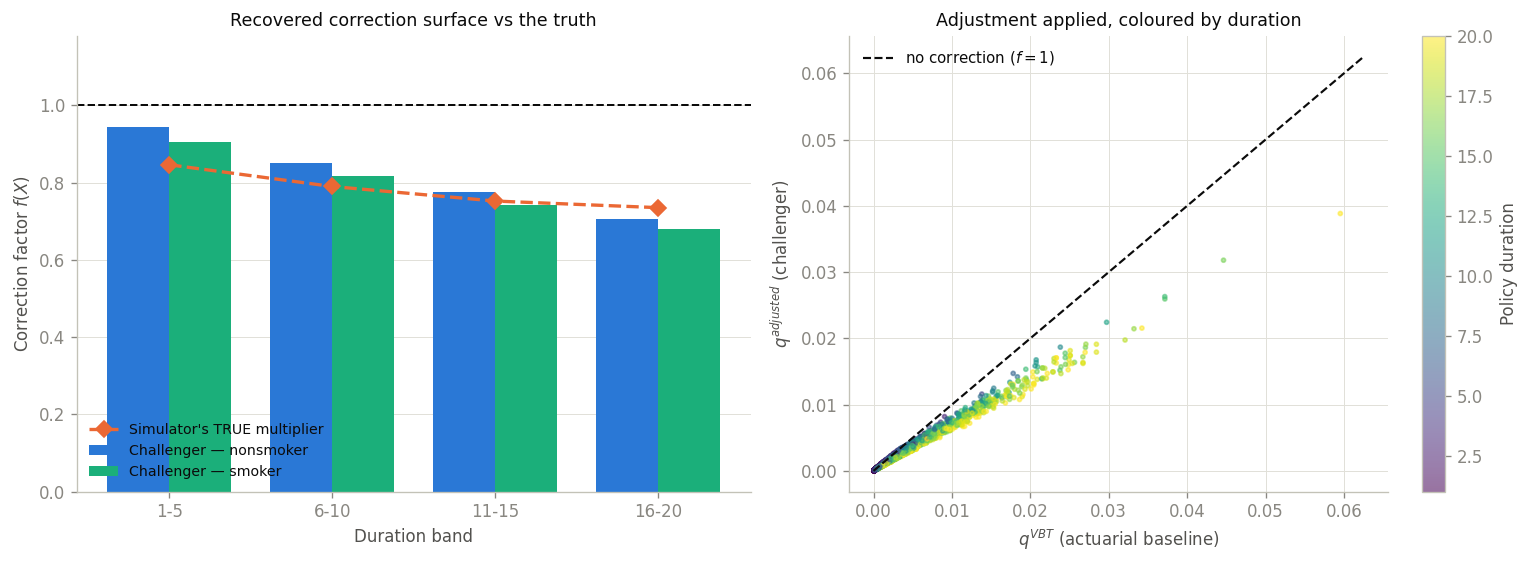

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

bands = list(surface.index.astype(str))
positions = np.arange(len(bands))
width = 0.38

ax1.bar(positions - width / 2, surface[surface.columns[0]], width=width, color=BLUE,
        label=f"Challenger — {surface.columns[0]}", zorder=2)
ax1.bar(positions + width / 2, surface[surface.columns[1]], width=width, color=AQUA,
        label=f"Challenger — {surface.columns[1]}", zorder=2)
ax1.plot(positions, [true_by_band[b] for b in bands], color=ORANGE, marker="D", markersize=7,
         linewidth=2, linestyle="--", label="Simulator's TRUE multiplier", zorder=3)
ax1.axhline(1.0, color=INK, linestyle="--", linewidth=1.2, zorder=1)
ax1.set_xticks(positions)
ax1.set_xticklabels(bands)
ax1.set_xlabel("Duration band")
ax1.set_ylabel("Correction factor $f(X)$")
ax1.set_title("Recovered correction surface vs the truth", fontsize=10.5)
ax1.set_ylim(0, 1.18)
ax1.legend(frameon=False, fontsize=8.5, loc="lower left")
style(ax1)

sample = data.sample(min(6000, len(data)), random_state=1)
scatter = ax2.scatter(sample["baseline_p"], sample["challenger_p"], s=6,
                      c=sample["duration"], cmap="viridis", alpha=0.55, zorder=2)
upper_limit = sample["baseline_p"].max() * 1.05
ax2.plot([0, upper_limit], [0, upper_limit], color=INK, linestyle="--", linewidth=1.3,
         label="no correction ($f = 1$)", zorder=3)
ax2.set_xlabel("$q^{VBT}$ (actuarial baseline)")
ax2.set_ylabel("$q^{adjusted}$ (challenger)")
ax2.set_title("Adjustment applied, coloured by duration", fontsize=10.5)
ax2.legend(frameon=False, fontsize=9, loc="upper left")
fig.colorbar(scatter, ax=ax2, label="Policy duration")
style(ax2, axis="both")

plt.tight_layout()
plt.show()

The recovered surface declines monotonically with duration — from roughly 0.94 in durations 1–5 to
about 0.70 in durations 16–20 — which is the correct *shape*: the simulator's true multiplier falls
from 0.85 to 0.74 over the same span. The model has found the real pattern.

It has also **over-extrapolated it**, and the reason is instructive. Model 2 enters duration as a
single linear term in the log-odds, so it fits a straight line through a true effect that is
actually a step function flattening out after duration 10. The fitted line is therefore too high
early and too low late. This is the standard cost of a parsimonious specification, and with the
duration coefficient statistically insignificant (Part 4), the honest response is not to use this
surface as an assumption — it is to keep the level correction, note the duration pattern as
consistent with the ILEC data, and revisit when more exposure has accumulated.

The smoker/nonsmoker split shows almost no separation, matching Part 4: after the table's own
prediction is accounted for, smoker status carries no additional information.

### What the challenger concluded

1. **The table's risk differentiation is sound.** The calibration slope sits on 1.00, discrimination
   (AUC ≈ 0.80, monotone lift across all ten deciles) is good, and no policy characteristic adds
   information once the table's prediction is in the model.
2. **The table's level is biased.** It over-predicts deaths by roughly a quarter, visible as a
   calibration curve below the diagonal and an O/E near 0.74 — and correctable by a single scalar,
   which is the easiest possible finding to act on.
3. **A duration pattern is present but unproven.** Correctly signed, roughly the right magnitude,
   and not statistically significant at this book size.
4. **AUC was the wrong metric for the question.** It could not detect the one problem the table
   actually has, and the challenger that fixed that problem scored marginally *worse* on it.

None of this changes the pricing engine — the challenger has no write access to the assumptions,
by design. What it produces is evidence for the assumption-setting process, and the credibility
machinery in notebook 07, Part 8 is what turns that evidence into a premium.